# Bathymetric profiles for SWASH

In this notebook, we will **generate and visualize simple bathymetric profiles** for SWASH.

We will explore different profile shapes and select one to save as `templates/depth.bot` for later use in a SWASH simulation.

No external data or SWASH execution is required.

In [1]:
import os.path as op
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bluemath_tk.topo_bathy.profiles import reef, linear, parabolic, biparabolic, custom_profile
from utils.plotting import plot_depthfile

cwd = Path.cwd().resolve()
templates_dir = cwd / "templates"
dx = 1.0  # m
examples = {}
print(f"Output directory: {templates_dir}")


Output directory: /workspaces/BlueMath_Course_Corvallis/methods/hybrid_downscaling/metamodel/hyswash/templates


In [2]:
import inspect
from bluemath_tk.wrappers.swash.swash_wrapper import HySwashModelWrapper

print(inspect.getfile(HySwashModelWrapper))

/opt/conda/lib/python3.11/site-packages/bluemath_tk/wrappers/swash/swash_wrapper.py


## Real profile

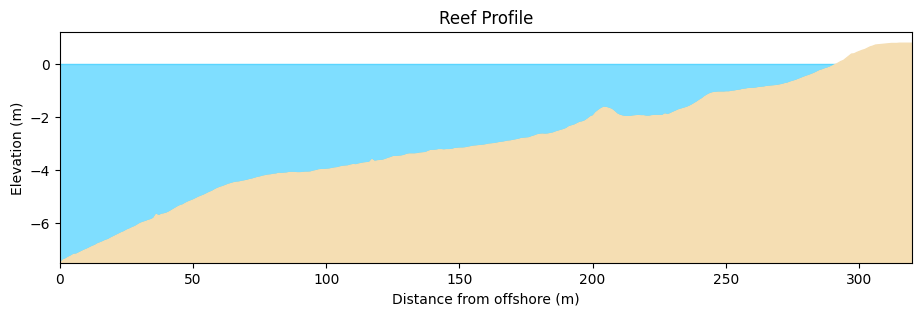

In [3]:
file = op.join(templates_dir, "coral_reef_profile.bot")
depth = np.loadtxt(file)
examples["real"] = (depth, dx)
plot_depthfile(depth, dxinp=1)
plt.title('Reef Profile')
plt.show()


## Setup and conventions

Before creating our profiles, let's define a few conventions:

- All distances and elevations are in **meters**.
- `x` increases from **offshore toward land**.
- `depth > 0` represents submerged bed.
- `depth = 0` is the reference water level.
- `depth < 0` represents exposed ground.
- In the figures, we plot bed elevation as `z = -depth`.

The profile-generation functions use the following parameters:

| Parameter | Description | Units |
|:----------|:------------|:-----:|
| `dx` | Horizontal spacing between nodes | m |
| `h0` | Offshore or maximum construction depth | m |
| `Slope1` | Fore-reef slope | m/m |
| `Slope2` | Inner beach slope | m/m |
| `m` | Beach slope | m/m |
| `Wreef` | Width of the reef flat | m |
| `Wfore` | Length of the initial offshore section | m |
| `bCrest` | Height of the exposed beach or crest | m |
| `emsl` | Water elevation or reef-flat depth, depending on the profile | m |
| `A` | Equilibrium-profile shape coefficient | m¹ᐟ³ |
| `xBeach` | Length used to construct the exposed beach | m |
| `hsig` | Significant wave height | m |
| `omega_surf_list` | Dimensionless fall velocity parameter (1–5); pass a **scalar** despite its name | – |
| `TR` | Tidal range (high tide − low tide) | m |
| `xs` | Strictly increasing horizontal coordinates | m |
| `ys` | Bed elevations, positive upward | m |

## 1. Reef profile

Let's start with a **reef-type bathymetric profile**, consisting of four main sections:

**offshore flat → fore-reef slope → reef flat → beach slope**

The `reef` function generates this geometry from a small set of parameters.

### Example

We will use a **15 m offshore depth**, a **200 m-wide reef flat**, and a
**2.5 m reef-flat depth**.

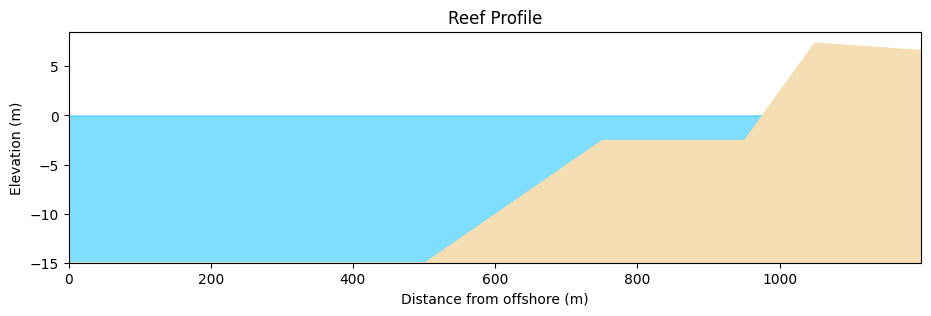

In [4]:
reef_parameters = dict(
    dx=dx, h0=15.0, Slope1=0.05, Slope2=0.10,
    Wreef=200.0, Wfore=500.0, bCrest=10.0, emsl=2.5,
)
depth_reef = reef(**reef_parameters)
examples["reef"] = (depth_reef, dx)
plot_depthfile(depth_reef)
plt.title('Reef Profile')
plt.show()


## 2. Linear beach

The `linear` function creates a simple beach profile consisting of two main sections:

**offshore flat → constant beach slope**

The beach extends above the zero reference level to form an exposed section.

### Example

We will use a **15 m offshore depth**, a **0.05 beach slope**, and a
**500 m-long offshore flat**.

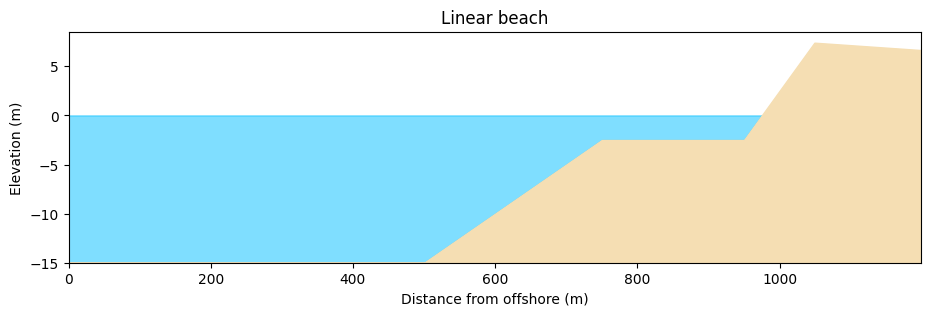

In [5]:
linear_parameters = dict(dx=dx, h0=15.0, bCrest=5.0, m=0.05, Wfore=200.0)
depth_linear = linear(**linear_parameters)
examples["linear"] = (depth_linear, dx)
plot_depthfile(depth_reef)
plt.title("Linear beach")
plt.show()


## 3. Parabolic beach

The `parabolic` function creates a beach profile whose submerged section follows the equilibrium profile:

$$
h = A x^{2/3}
$$

where $h$ is water depth, $x$ is the distance from the shoreline, and $A$ controls the shape of the profile.

The resulting profile consists of:

**parabolic submerged profile → linear exposed beach**

### Example

We will use a **15 m offshore depth**, a profile coefficient of
**$A = 0.15\ \mathrm{m}^{1/3}$**, and a **10 m-high exposed beach**.

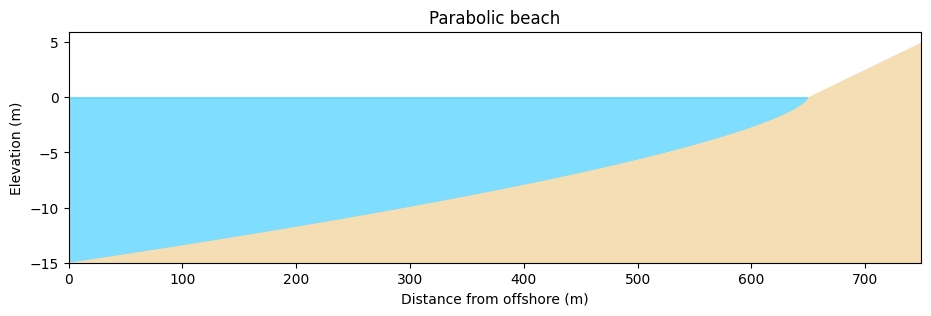

In [6]:
parabolic_parameters = dict(dx=dx, h0=15.0, A=0.20, xBeach=100.0, bCrest=5.0)
depth_parabolic = parabolic(**parabolic_parameters)
examples["parabolic"] = (depth_parabolic, 1.0)
plot_depthfile(depth_parabolic)
plt.title("Parabolic beach")
plt.show()


## 4. Biparabolic beach

The `biparabolic` function creates a beach profile by combining **two empirical
profile expressions**, representing different regions of the submerged beach.

The transition between the two regions occurs at the depth:

$$
h_r = 1.1 H_s + TR
$$

where $H_s$ is the significant wave height and $TR$ is the tidal range.

Unlike the previous profiles, this function does not use `dx`: the resulting
profile has a fixed **1 m horizontal spacing**.

### Example

We will generate a biparabolic profile using a **15 m offshore depth**,
a significant wave height of **2 m**, and a tidal range of **1 m**.

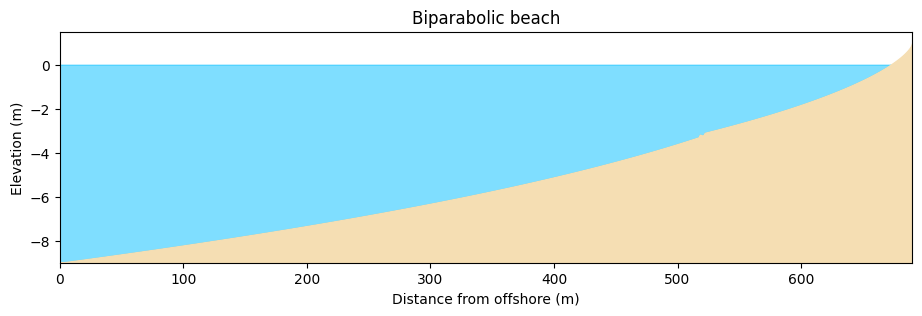

In [7]:
biparabolic_parameters = dict(h0=10.0, hsig=2.0, omega_surf_list=3.0, TR=2.0)
depth_biparabolic = biparabolic(**biparabolic_parameters)
examples["biparabolic"] = (depth_biparabolic, 1.0)
plot_depthfile(depth_biparabolic)
plt.title("Biparabolic beach")
plt.show()


## 5. Custom profile

The `custom_profile` function creates a bathymetric profile from a set of
**user-defined points**, using linear interpolation between them.

The input coordinates represent:

- `xs`: horizontal distance, increasing from offshore toward land.
- `ys`: bed elevation, positive upward.

The elevations are converted to water depth as:

$$
depth = emsl - elevation
$$

For example, a bed elevation of **−8 m** with a water level of **+1 m**
corresponds to a water depth of **9 m**.

### Example

We will define a simple profile from a few bathymetric points and interpolate
them at **1 m horizontal spacing**.

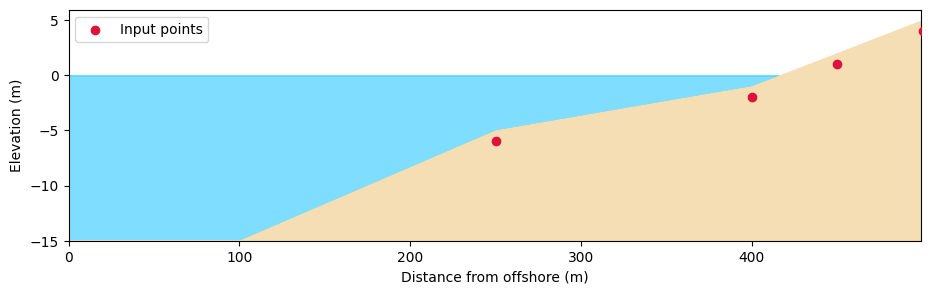

In [8]:
xs = np.array([0, 100, 250, 400, 450, 500], dtype=float)
ys = np.array([-15, -15, -5, -1, 2, 5], dtype=float)
emsl_custom = 1.0
depth_custom = custom_profile(dx=dx, emsl=emsl_custom, xs=xs, ys=ys)
examples["custom"] = (depth_custom, dx)
ax = plot_depthfile(depth_custom)
ax.scatter(xs - xs[0], ys - emsl_custom, color="crimson", label="Input points", zorder=3)
ax.legend()
plt.show()


## Select and export a profile

Now that we have explored the different bathymetric profiles, let's select one
and export it for use in SWASH.

Choose one of:

`"reef"` · `"linear"` · `"parabolic"` · `"biparabolic"` · `"custom"`

If you modify any profile parameters, remember to rerun the corresponding cell
before exporting it.

The selected profile will be saved as:

`templates/depth.bot`

The file contains **one depth value per line**, in meters, with no header or
horizontal coordinates.

> **⚠️ Warning**
> Running the export cell will **overwrite** any existing `templates/depth.bot` file.

Saved: /workspaces/BlueMath_Course_Corvallis/methods/hybrid_downscaling/metamodel/hyswash/templates/depth.bot
mxinp = 1199
dxinp = 1 m
Bathymetry length = 1199 m


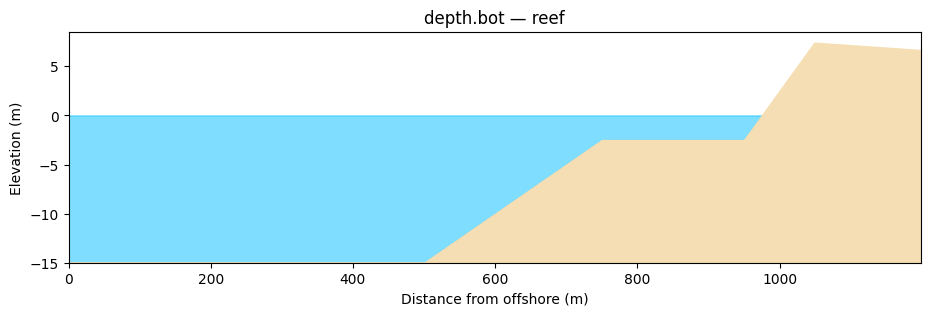

In [9]:
selected_profile = "reef"

# Select profile
depth, dxinp = examples[selected_profile]

# Export
templates_dir.mkdir(parents=True, exist_ok=True)
output_path = templates_dir / "depth.bot"
np.savetxt(output_path, depth, fmt="%.6f")

# SWASH grid parameters
mxinp = len(depth) - 1

print(f"Saved: {output_path}")
print(f"mxinp = {mxinp}")
print(f"dxinp = {dxinp:g} m")
print(f"Bathymetry length = {mxinp * dxinp:g} m")

# Visualize exported profile
plot_depthfile(depth, dxinp=dxinp)
plt.title(f"depth.bot — {selected_profile}")
plt.show()

## Summary

In this notebook, we:

- Generated and visualized several bathymetric profiles: **reef, linear, parabolic, biparabolic, and custom**.
- Explored how different parameters control the shape of each profile.
- Selected one profile and exported it as `templates/depth.bot` for use in SWASH.

## What's next?

In the next notebook, we will use this bathymetry to **build a HySwash case and run SWASH**.

In this notebook, we have a selection of example bathymetric profiles, including reef, linear, parabolic, biparabolic, and custom profiles. 
The selected profile has been saved to a file named `depth.bot` in the `templates` directory. 